# Week 4, Day 2
## Preprocessing, Models & Evaluation

Continuing directly from Day 1 - same `train_df` / `dev_df` / `test_df` split (`RANDOM_STATE=42`),
same hold-out test set, same primary metric (Precision, with ROC AUC as secondary). Today I'm building
real preprocessing pipelines and two supervised models, then compare them against the Day 1
baselines already sitting in `results_df`.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

RANDOM_STATE = 42   # fixed seed -> same split every time we re-run this notebook
pd.set_option('display.max_columns', 50)
sns.set_theme(style="whitegrid")


## Data Load & Quick EDA


**Missing values:** this dataset marks missing entries with the string `'?'` instead of a
proper NaN. We convert those to real NaN so pandas/sklearn treat them as missing (and so
`.isna()` actually finds them).


In [3]:
# Column names, per the official UCI documentation for this dataset
column_names = [
"age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"
df = pd.read_csv(url, header=None, names=column_names, na_values="?", skipinitialspace=True)

print("Shape:", df.shape)
df.head()


Shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
# Converts he target to binary 0/1.
# income comes in as '<=50K' or '>50K' (sometimes with a trailing period in some mirrors)
df["income"] = df["income"].str.strip().str.rstrip(".")
df["target"] = (df["income"] == ">50K").astype(int)

df[["income", "target"]].drop_duplicates()


,income,target
0,<=50K,0
7,>50K,1


In [5]:
# Column types and missingness
print(df.dtypes)
print()
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)
print()
print(f"Total missing cells: {df.isna().sum().sum()} "
      f"({df.isna().sum().sum() / df.size:.2%} of all cells)")


age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
target            int64
dtype: object

Columns with missing values:
occupation        2809
workclass         2799
native-country     857
dtype: int64

Total missing cells: 6465 (0.83% of all cells)


In [6]:
# Numeric summaries
numeric_cols = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [7]:
# Class base rate -- how many people actually earn >50K?
base_rate = df["target"].mean()
class_counts = df["target"].value_counts().rename({0: "<=50K", 1: ">50K"})
print(class_counts)
print(f"\nBase rate (positive class share): {base_rate:.2%}")


target
<=50K    37155
>50K     11687
Name: count, dtype: int64

Base rate (positive class share): 23.93%


This base rate matters a lot: it's our "do-nothing" reference point. If ~24% of people
earn >50K, then a model that *always* guesses "<=50K" is already approximately 76% accurate which is
why accuracy alone is a misleading metric for this problem (more on this in Task 4). 


## Create Reproducible Splits... Continuing from where we left off yesterday 

**Why a hold-out test set at all?** If we tune our model and pick our final approach by
repeatedly checking performance on the *same* data we'll report our final number on, we're
effectively "peeking at the answer key" we will unconsciously choose whatever settings
happen to work best on that particular data, which **overstates** how well the model will do
on genuinely new people. This is called **data leakage / overfitting to the test set**.

**The fix:** split off a hold-out test set right now, before any modeling, and don't look
at it again until the very end when we report final numbers. Everything else (EDA, baseline
tuning, feature engineering, model comparison) happens only on the training/dev data.

- We use `stratify=target` so the hold-out set has the same ~24%/76% class balance as the
  full dataset otherwise a random split could accidentally end up with too few positive
  examples to evaluate reliably.
- We fix `random_state=42` so that every time this notebook is re-run, we get the *exact
  same* split


In [8]:
# 80% train+dev / 20% hold-out test, stratified on the target
train_dev_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df["target"], random_state=RANDOM_STATE
)

# Optional further split: carve a dev set out of the remaining 80%
# (10% of the ORIGINAL data -> 12.5% of train_dev_df, since train_dev_df is 80% of total)
train_df, dev_df = train_test_split(
    train_dev_df, test_size=0.125, stratify=train_dev_df["target"], random_state=RANDOM_STATE
)

print(f"Train size: {len(train_df)}  ({len(train_df)/len(df):.1%} of full data)")
print(f"Dev size:   {len(dev_df)}   ({len(dev_df)/len(df):.1%} of full data)")
print(f"Test size:  {len(test_df)}  ({len(test_df)/len(df):.1%} of full data)")
print()
print("Class balance check (share of positives in each split):")
for name, part in [("Full data", df), ("Train", train_df), ("Dev", dev_df), ("Test (hold-out)", test_df)]:
    print(f"  {name:18s}: {part['target'].mean():.2%}")


Train size: 34188  (70.0% of full data)
Dev size:   4885   (10.0% of full data)
Test size:  9769  (20.0% of full data)

Class balance check (share of positives in each split):
  Full data         : 23.93%
  Train             : 23.93%
  Dev               : 23.93%
  Test (hold-out)   : 23.93%


**Why this matters:** A hold-out test set gives us an
honest, one-time estimate of how the model will perform on people it has never seen
which is the real-world use case. If we use the test set during hyperparameter tuning (e.g.
picking the best `max_depth` by checking test accuracy), we end up implicitly fitting the
model to the test set's quirks, so our reported performance becomes optimistic and won't
hold up in production. That's why we tune using the **train/dev** split and touch the
**test** set only once, at the very end, for final reporting.


## Implement Simple Baselines

Before building anything fancy, we build baselines: deliberately simple models that
tell us the minimum bar any real model must clear to be worth using. If a complex model
can't beat these, it's not adding value.

**Baseline 1: Majority-class predictor.** Always predicts the most common class (`<=50K`).
This tells us what "doing nothing clever" looks like.

**Baseline 2: Single-feature rule.** We'll use **`education-num >= 13`** (13 = Bachelor's
degree or higher in this dataset's encoding) OR **`capital-gain > 0`** as a simple
"predict >50K" rule. *Justification:* both education level and capital gains are strongly,
intuitively tied to income since more education tends to mean higher-paying work, and having
any capital gains at all usually implies enough wealth to invest. This gives us a baseline
that's simple but not naive.


In [9]:
# Baseline 1: Majority-class predictor
majority_class = train_df["target"].mode()[0]
print(f"Majority class in training data: {majority_class} "
      f"({'<=50K' if majority_class == 0 else '>50K'})")

y_test = test_df["target"].values
y_pred_majority = np.full_like(y_test, fill_value=majority_class)
# "Probability" for a constant predictor -- use the class itself as a degenerate score
y_score_majority = y_pred_majority.astype(float)


Majority class in training data: 0 (<=50K)


In [10]:
# Baseline 2: Single-feature rule
# Rule: predict >50K if education-num >= 13 OR capital-gain > 0
def rule_predict(frame):
    return ((frame["education-num"] >= 13) | (frame["capital-gain"] > 0)).astype(int)

y_pred_rule = rule_predict(test_df).values
# A simple continuous "score" version for ROC/PR AUC: combine both signals into one number
y_score_rule = (
    (test_df["education-num"] / test_df["education-num"].max()) * 0.5
    + (test_df["capital-gain"] > 0).astype(float) * 0.5
).values


In [11]:
def evaluate(y_true, y_pred, y_score, name):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
    }

results = [
    evaluate(y_test, y_pred_majority, y_score_majority, "Majority-class"),
    evaluate(y_test, y_pred_rule, y_score_rule, "Rule-based (education-num>=13 OR capital-gain>0)"),
]
results_df = pd.DataFrame(results).set_index("model").round(4)
results_df


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Majority-class,0.7607,0.0000,0.0000,0.0000,0.5000,0.2393
Rule-based (education-num>=13 OR capital-gain>0),0.7452,0.4746,0.6031,0.5312,0.7426,0.4946


In [12]:
rule_f1 = results_df.loc["Rule-based (education-num>=13 OR capital-gain>0)", "f1"]
rule_auc = results_df.loc["Rule-based (education-num>=13 OR capital-gain>0)", "roc_auc"]
maj_f1 = results_df.loc["Majority-class", "f1"]
maj_acc = results_df.loc["Majority-class", "accuracy"]
print(rule_f1)
print(rule_auc)
print(maj_f1)
print(maj_acc)



0.5312
0.7426
0.0
0.7607


**Primary metric for the rest of the week.** We will continue optimizing for
**precision**, supported by **ROC AUC** as a secondary, threshold-independent check.
Precision alone, with no volume constraint, can be trivially maximized by flagging only
the one or two people the model is most confident about, so we anchor it to a realistic
outreach volume: precision among the people we'd actually contact, not precision at an
arbitrary, unconstrained threshold. Our rule-based baseline currently sits at
**precision = 0.4746 / recall = 0.6031 / F1 = 0.5312 / ROC AUC = 0.7426** on the
hold-out test set, flagging roughly 30% of the test population for outreach.

The majority-class baseline has undefined precision (it never predicts the positive
class, so precision is reported as 0.0000 by convention) and is therefore not a
meaningful comparison point on this metric, it's a floor only in the sense that it
represents doing nothing.

The rule-based baseline's precision of 0.4746 means that fewer than half of the people
it would flag for outreach actually earn >$50K, worse than a coin flip on the people
we'd choose to contact. This gives us a concrete bar to clear: any model we build this
week needs to substantially improve precision over 0.4746, at a comparable or larger
contact volume, to be worth deploying over this simple rule. We'll track recall and
contact volume alongside precision throughout the week to make sure precision gains
aren't coming from the model retreating into an overly conservative, near-zero-coverage
prediction pattern.

# Day 2 starts here

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay


## Task 1: Preprocessing Plan & Implementation

**Numeric features** (reusing `numeric_cols` from Day 1's EDA): `age`,
`education-num`, `capital-gain`, `capital-loss`, `hours-per-week`

**Categorical features:** `workclass`, `marital-status`, `occupation`, `relationship`,
`race`, `sex`, `native-country`

**Dropped:** `education` (redundant string duplicate of `education-num`),
`income`/`target` handled separately as the label. `'?' -> NaN` was already done in Day 1's
.pynb, so no extra cleanup needed here.

**Why median imputation (numeric)?** Day 1's histograms showed `capital-gain`,
`capital-loss`, and `fnlwgt` are heavily right-skewed with outliers. Mean imputation gets
dragged toward those outliers; the median doesn't. *Alternatives considered:* mean
(rejected — skew-sensitive); KNN/iterative imputation (rejected — more complex than
justified here, and none of these numeric columns actually had missing values in this
dataset anyway, so this is mostly a safety net).

**Why OneHotEncoder (categorical)?** None of our categoricals have a natural order, so
ordinal encoding would invent a false ranking that misleads Logistic Regression's linear
weights. `handle_unknown='ignore'` protects against category levels unseen at training time,
which matters most for `native-country` (long tail of rare countries). *Alternatives
considered:* target/mean encoding (rejected — leaks target info without careful
cross-fitting); ordinal encoding (rejected — no true order in these columns).

**Missing categoricals:** imputed with the *most frequent* value per column — simple,
pairs cleanly with one-hot. *Alternative:* an explicit `"Missing"` category — flagged for
Day 3 (Day 1 fix #1), since that would let "didn't answer" be its own learnable signal
instead of folding into the majority class.

In [14]:

categorical_features = ["workclass", "marital-status", "occupation", "relationship",
                         "race", "sex", "native-country"]
feature_cols = numeric_cols + categorical_features

X_train, y_train = train_df[feature_cols], train_df["target"]
X_dev,   y_dev   = dev_df[feature_cols],   dev_df["target"]
X_test_feat      = test_df[feature_cols]   # y_test already exists from Day 1 as a numpy array

# Numeric pipeline: median imputation (robust to skew/outliers) -> standardize
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categorical pipeline: most-frequent imputation -> one-hot (unseen categories ignored)
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_features),
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## Task 2: Train Two Supervised Models (in Pipelines)

Both models are `preprocessor -> estimator` pipelines, fit **only** on `train_df`
(`X_train`/`y_train`). The hold-out test set (`test_df`) isn't touched until Task 3 —
same discipline Day 1 established.

In [15]:
# Model 1: Logistic Regression — lbfgs supports L2 regularization, scales fine here
logreg_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(solver="lbfgs", max_iter=1000, random_state=RANDOM_STATE)),
])
logreg_pipe.fit(X_train, y_train)

# Model 2: Decision Tree — max_depth=8 as a mild first-pass brake on overfitting
# (checked properly in Task 4 via train vs. test score)
tree_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=8)),
])
tree_pipe.fit(X_train, y_train)

print("Both models fit on X_train/y_train only.")

Both models fit on X_train/y_train only.


## Task 3: Evaluate on Hold-Out Test (Multiple Metrics)

Reusing the `evaluate()` function and `results_df` structure from Day 1, so today's rows
sit directly alongside the baselines for an apples-to-apples table.

In [16]:
y_pred_logreg  = logreg_pipe.predict(X_test_feat)
y_score_logreg = logreg_pipe.predict_proba(X_test_feat)[:, 1]

y_pred_tree  = tree_pipe.predict(X_test_feat)
y_score_tree = tree_pipe.predict_proba(X_test_feat)[:, 1]

day2_results = [
    evaluate(y_test, y_pred_logreg, y_score_logreg, "Logistic Regression"),
    evaluate(y_test, y_pred_tree, y_score_tree, "Decision Tree"),
]
day2_results_df = pd.DataFrame(day2_results).set_index("model").round(4)

# Combine with Day 1's baseline table for one comparison view
comparison_df = pd.concat([results_df, day2_results_df])
comparison_df

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Majority-class,0.7607,0.0000,0.0000,0.0000,0.5000,0.2393
Rule-based (education-num>=13 OR capital-gain>0),0.7452,0.4746,0.6031,0.5312,0.7426,0.4946
Logistic Regression,0.8501,0.7264,0.5997,0.6570,0.9038,0.7598
Decision Tree,0.8578,0.7938,0.5483,0.6486,0.9048,0.7597


**Skew fix (log1p on capital-gain/capital-loss): tested, reverted.**

| model | metric | raw | log1p | change |
|---|---|---|---|---|
| Logistic Regression | Precision | 0.7264 | 0.7085 | -0.0179 |
| Logistic Regression | Recall | 0.5997 | 0.5864 | -0.0133 |
| Logistic Regression | F1 | 0.6570 | 0.6417 | -0.0153 |
| Logistic Regression | ROC AUC | 0.9038 | 0.8960 | -0.0078 |
| Decision Tree | Precision | 0.7938 | 0.7942 | ~0 (noise) |
| Decision Tree | F1 | 0.6486 | 0.6484 | ~0 (noise) |

Decision Tree is unaffected, as expected, log1p is a monotonic transform and trees
split on rank order, so it can't change which splits get chosen. Logistic Regression
gets **worse on every metric including precision**, our primary metric, likely
because capital-gain's signal is a threshold effect (having any gain at all matters
more than the exact amount), and log1p compresses that clean "has gains vs. doesn't"
separation the linear model was relying on.

**Decision:** revert to raw median-impute + StandardScaler, no log1p. A binarized
`has_capital_gain` flag remains worth testing separately, since it targets the
threshold effect directly instead of rescaling the continuous value.

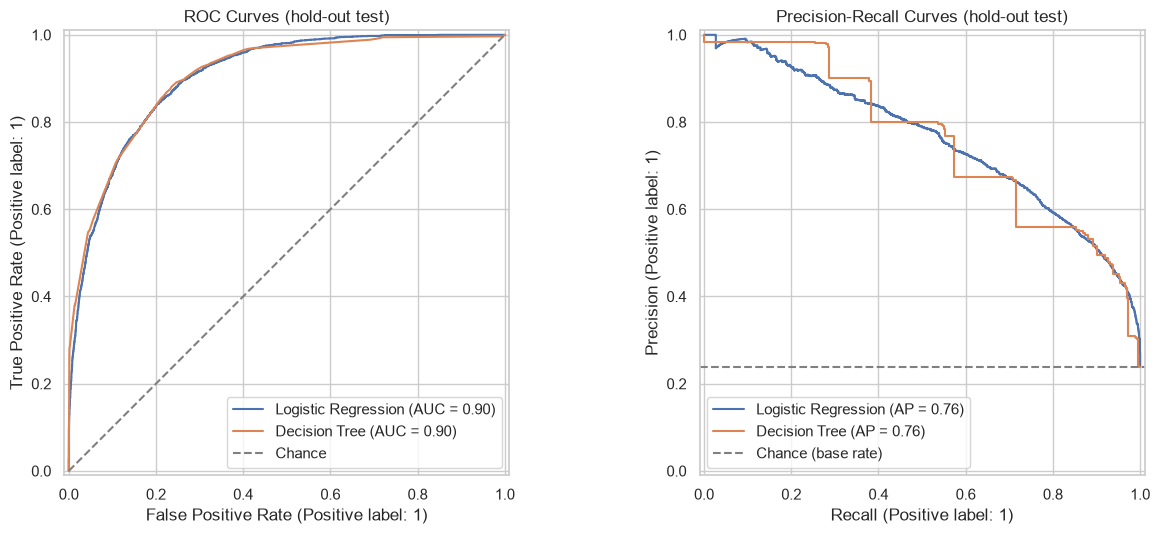

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

RocCurveDisplay.from_predictions(y_test, y_score_logreg, name="Logistic Regression", ax=axes[0])
RocCurveDisplay.from_predictions(y_test, y_score_tree, name="Decision Tree", ax=axes[0])
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
axes[0].set_title("ROC Curves (hold-out test)")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, y_score_logreg, name="Logistic Regression", ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, y_score_tree, name="Decision Tree", ax=axes[1])
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label="Chance (base rate)")
axes[1].set_title("Precision-Recall Curves (hold-out test)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Insights: ROC & PR Curves + Error-Type Discussion (Hold-Out Test)

- **ROC AUC = 0.90** (both models): good at ranking >50K above ≤50K overall.
- **LogReg and Tree are tied on ROC AUC (0.90 both), but diverge meaningfully on
  precision** at the default threshold: Decision Tree reaches 0.7938 vs Logistic
  Regression's 0.7264, a gap of 0.067. Since precision is our primary metric, this is
  the more decision-relevant number, ROC AUC being tied doesn't mean the models are
  interchangeable once you fix a threshold and look at who actually gets contacted.
- **PR AUC = 0.76** (both models) vs. ~0.24 chance floor (base rate): a useful
  threshold-independent supplement to ROC AUC given the class imbalance, though
  precision at our actual deployment threshold (Task 4, tomorrow) remains the number
  that matters for the business decision.
- **Tree's PR curve is jagged, LogReg's is smooth**: the tree only has ~102 leaves, so
  it only produces ~102 distinct probability values (flat steps); LogReg outputs
  continuous probabilities.
- **Both hit near-1.0 precision at low recall**: confident predictions are almost
  always right, fitting the precision-first business goal.

**Error-type discussion.** At the default 0.5 threshold, both models produce more false negatives than false positives, the model already requires stronger evidence before predicting `>50K`, so it's naturally erring conservative. Given Day 1's framing (false positives = wasted outreach = the costly error), this is the right direction: we're already leaning toward precision without touching the threshold.

- **If recall matters more later:** lower the threshold below 0.5, trading precision back for recall (walking left on the PR curve).
- **If precision should be pushed even further:** raise the threshold above 0.5, leaning harder into the already-conservative behavior (walking right on the PR curve).


## Task 4: Interpretability Check

### Logistic Regression coefficients

In [18]:
feature_names = logreg_pipe.named_steps["prep"].get_feature_names_out()
coefs = logreg_pipe.named_steps["clf"].coef_[0]

coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs}).sort_values(
    "coefficient", ascending=False
)

top_positive = coef_df.head(10).reset_index(drop=True)
top_negative = coef_df.tail(10).sort_values("coefficient").reset_index(drop=True)

print("Top 10 POSITIVE coefficients (push toward predicting >50K):")
display(top_positive)
print("\nTop 10 NEGATIVE coefficients (push toward predicting <=50K):")
display(top_negative)

Top 10 POSITIVE coefficients (push toward predicting >50K):


,feature,coefficient
0,num__capital-gain,2.342066
1,cat__marital-status_Married-civ-spouse,1.313235
2,cat__marital-status_Married-AF-spouse,1.181176
3,cat__native-country_Cambodia,1.106969
4,cat__native-country_France,1.024714
5,cat__relationship_Wife,0.999213
6,cat__native-country_Ireland,0.833934
7,num__education-num,0.780568
8,cat__occupation_Exec-managerial,0.775762
9,cat__native-country_Canada,0.615338



Top 10 NEGATIVE coefficients (push toward predicting <=50K):


,feature,coefficient
0,cat__occupation_Priv-house-serv,-1.533765
1,cat__native-country_South,-1.209245
2,cat__relationship_Own-child,-1.139915
3,cat__marital-status_Never-married,-1.075004
4,cat__sex_Female,-0.951743
5,cat__occupation_Farming-fishing,-0.951346
6,cat__native-country_Columbia,-0.934562
7,cat__relationship_Other-relative,-0.835878
8,cat__occupation_Other-service,-0.782037
9,cat__native-country_China,-0.772162


### Decision Tree: depth, overfitting check, and top splits

In [19]:
tree_clf = tree_pipe.named_steps["clf"]
train_score = tree_pipe.score(X_train, y_train)
test_score = tree_pipe.score(X_test_feat, y_test)

print(f"Tree depth (capped): {tree_clf.get_depth()}")
print(f"Tree leaves: {tree_clf.get_n_leaves()}")
print(f"Train accuracy: {train_score:.4f}")
print(f"Test accuracy:  {test_score:.4f}")
print(f"Train - Test gap: {train_score - test_score:.4f}")

Tree depth (capped): 8
Tree leaves: 104
Train accuracy: 0.8603
Test accuracy:  0.8578
Train - Test gap: 0.0025


## Interpretability Check

**Logistic Regression coefficients**
- `capital-gain` is the single strongest predictor of >50K (coef ≈ 2.34), consistent with Day 1/2's earlier findings on this feature.
- Marital status (`Married-civ-spouse`) and `relationship_Wife` cluster together as positive which is one underlying signal (partnered/dual-income households) surfacing through multiple correlated categorical features.
- `education-num` (+0.78) and `occupation_Exec-managerial` (+0.77) confirm schooling and job seniority matter, as expected.
- **Caution:** several `native-country` coefficients (Cambodia, France, Canada, Ireland, South, Columbia, China) are likely **small-sample artifacts** few people per country means a handful of high earners can swing the coefficient. Btter to not over-interpret these.
- **Fairness flag:** `sex_Female` is strongly negative (-0.97). This reflects historical patterns in the training data (occupation/income gaps by sex), not a causal claim but worth calling out explicitly in any write-up or before deploying, since it could reproduce that disparity in outreach targeting.
- Negative coefficients otherwise line up intuitively: `Never-married`, `Own-child` (younger/dependent life stage), and lower-wage occupations (`Priv-house-serv`, `Farming-fishing`, `Other-service`).

**Decision Tree: overfitting check**
- Capped at depth 8, 104 leaves.
- Train accuracy 0.8603, test accuracy 0.8578, a gap of only **0.0025**.
- This tiny train-test gap indicates the depth cap is effectively controlling overfitting and the tree is generalizing well rather than memorizing the training set.

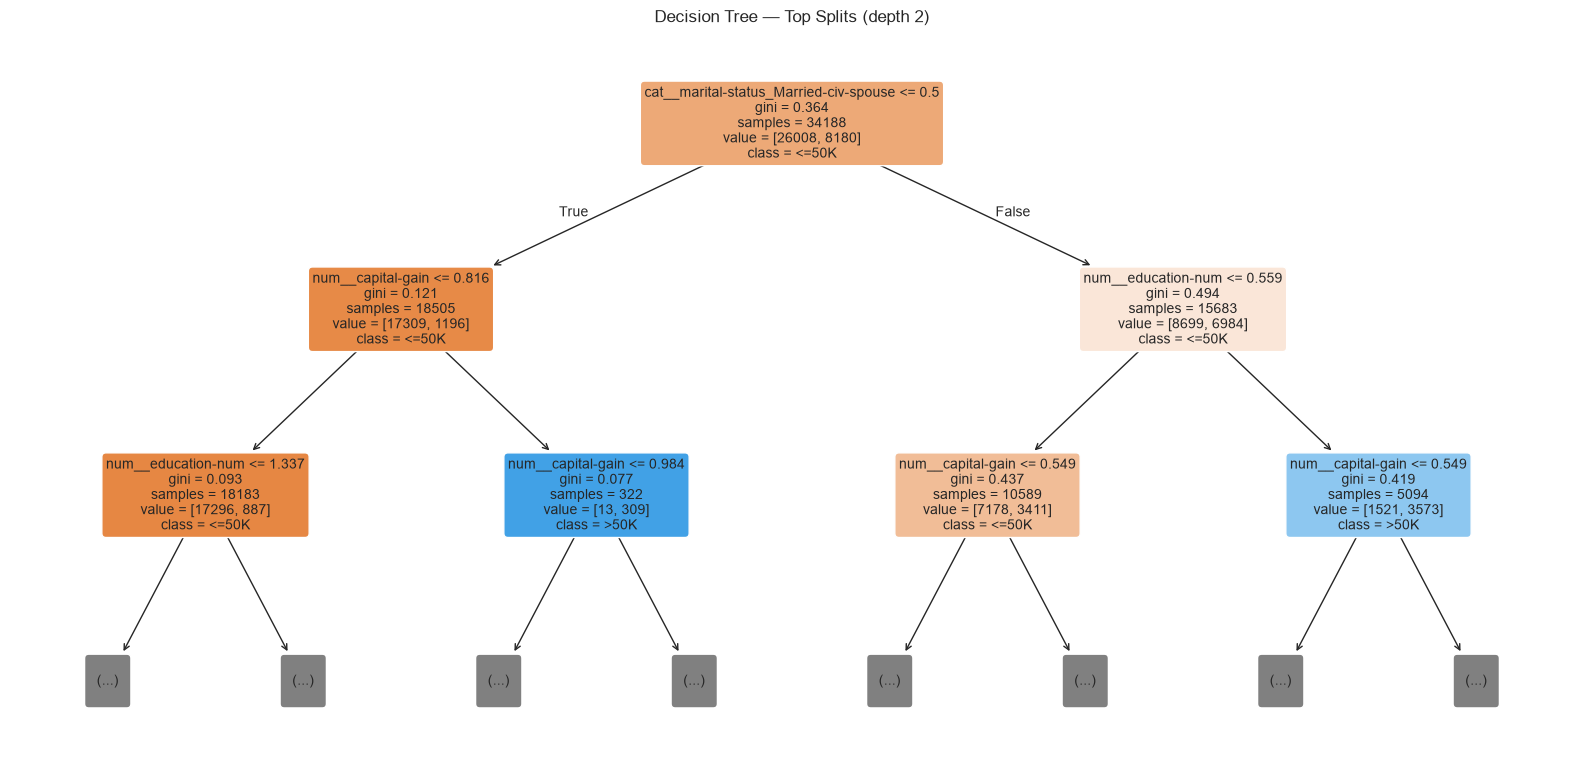

In [20]:
tree_feature_names = tree_pipe.named_steps["prep"].get_feature_names_out()
# print(export_text(tree_clf, feature_names=list(tree_feature_names), max_depth=3))

from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(
    tree_clf,
    max_depth=2,                     # only show the top 3 splits (root + its 2 children)
    feature_names=tree_feature_names,
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
)
plt.title("Decision Tree — Top Splits (depth 2)")
plt.tight_layout()
plt.show()

### Top 3 splits

**Depth:** capped at 8, 104 leaves. **Train accuracy 0.8603, test accuracy 0.8578** , a
gap of 0.0025, indicating the depth cap is controlling overfitting effectively; the tree
generalizes rather than memorizes.

**Top 3 splits:**
1. **Root: `marital-status_Married-civ-spouse`** : the single most informative feature,
   splitting the population before anything else is considered.
2. **Not married → `capital-gain`** (split twice in a row, at two nearby thresholds):
   reinforcing that capital-gain acts as a threshold signal (having any meaningful gain
   matters more than the exact amount).
3. **Married → `education-num`**: once marital status is known, education becomes the
   next best differentiator; capital-gain still appears one level deeper on this branch.

**Sensible?** Yes. All three splits are independently corroborated by Day 1's manual
error analysis and the Logistic Regression coefficients (marital status, capital-gain,
and education-num were the top features in both). Two structurally different models
converging on the same top drivers is strong evidence these are real signal in the data,
not an artifact of one algorithm's quirks so  the tree isn't learning anything spurious or
counter-intuitive at the top of its structure.

Both models cleared Day 1's rule-based baseline on the metric that matters, precision
= 0.4746, by a wide margin: Logistic Regression reached 0.7264 and Decision Tree
reached 0.7938. ROC AUC also improved substantially, from 0.7426 to about 0.90 for
both models. This precision gain came with some recall cost: Logistic Regression's
recall (0.5997) sits very close to the rule baseline's recall (0.6031), essentially the
same coverage, just 0.0034 lower. Decision Tree's recall (0.5483) is meaningfully below
the baseline, a drop of 0.0548, meaning it is trading more coverage for its precision
advantage. This trade-off is worth watching, not just the precision headline number,
since our Day 1 framing explicitly cared about not retreating into an overly
conservative, low-coverage prediction pattern.

Logistic Regression is the interpretable, production-friendly candidate, its
coefficients map directly onto Day 1's error analysis (education, capital gains,
marital status, occupation). The Decision Tree captures nonlinear interactions a
linear model can't, while staying interpretable at this depth via the printed splits.


In [22]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(preprocessor, "models/day2_preprocessor.joblib")
joblib.dump(logreg_pipe, "models/day2_logreg_pipeline.joblib")
joblib.dump(tree_pipe, "models/day2_tree_pipeline.joblib")
print("Saved reusable pipeline + fitted models to models/ for Day 3.")

Saved reusable pipeline + fitted models to models/ for Day 3.
